In [115]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import torch
from torch.utils.data import TensorDataset, DataLoader


sns.set_theme(style="whitegrid")

OSError: [WinError 1114] Procedura inicjowania biblioteki dołączanej dynamicznie (DLL) nie powiodła się. Error loading "c:\Users\bartek\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [ ]:
core_stocks = ["aapl", "msft", "googl", "amzn", "nvda", "jpm", "bac", "gs", "xom", "gld", "jnj", "ko"]  
data_path = "Data_clean/Stocks clean"
sp500_path = "Data_clean/ETF clean/spy_clean.csv"
combined_df = pd.DataFrame()

In [ ]:
for ticker in core_stocks:
    file_path = os.path.join(data_path, f"{ticker}_clean.csv")
    temp_df = pd.read_csv(file_path, index_col = "Date", parse_dates=True)
    combined_df[ticker] = temp_df["Close"]

sp500_df = pd.read_csv(sp500_path, index_col = "Date", parse_dates = True)

df = combined_df.copy()
df["spy"] = sp500_df["Close"]



In [ ]:
df = df.sort_index()
start_date = '2017-01-01'
df = df.loc[start_date:]
df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2017-01-02,114.15,61.3045,800.23,751.77,104.045,84.824,22.0615,238.265,87.2525,110.04,113.29,40.606,221.23
2017-01-03,114.31,61.5200,808.01,753.67,101.680,85.283,22.2740,239.310,87.5560,110.47,113.60,40.772,222.07
2017-01-04,114.19,61.2460,807.77,757.18,104.060,85.441,22.6890,240.870,86.5940,110.86,113.41,40.626,223.41
2017-01-05,114.77,61.2460,813.02,780.45,101.410,84.655,22.4220,239.060,85.3040,112.58,114.60,40.723,223.23
2017-01-06,116.04,61.7760,825.21,795.99,102.770,84.665,22.4220,242.610,85.2550,111.75,114.05,40.713,224.02


In [ ]:
returns_df = df[core_stocks].pct_change()
returns_df['spy'] = df['spy'].pct_change().shift(-1)
returns_df = returns_df.loc["2017-01-02":]
returns_df = returns_df.dropna()
returns_df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2017-01-03,0.001402,0.003515,0.009722,0.002527,-0.022731,0.005411,0.009632,0.004386,0.003478,0.003908,0.002736,0.004088,0.006034
2017-01-04,-0.001050,-0.004454,-0.000297,0.004657,0.023407,0.001853,0.018632,0.006519,-0.010987,0.003530,-0.001673,-0.003581,-0.000806
2017-01-05,0.005079,0.000000,0.006499,0.030732,-0.025466,-0.009199,-0.011768,-0.007514,-0.014897,0.015515,0.010493,0.002388,0.003539
2017-01-06,0.011066,0.008654,0.014993,0.019912,0.013411,0.000118,0.000000,0.014850,-0.000574,-0.007373,-0.004799,-0.000246,-0.003259
2017-01-09,0.009221,-0.003173,0.002387,0.001168,0.040576,0.000697,-0.005753,-0.008161,-0.016503,0.008233,-0.000175,-0.010070,0.000000


In [ ]:
X = returns_df[core_stocks]
y = returns_df["spy"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

In [ ]:
model = xgb.XGBRegressor(n_estimators = 100, learning_rate = 0.05, max_depth = 3, random_state = 42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 0.002781271990957859


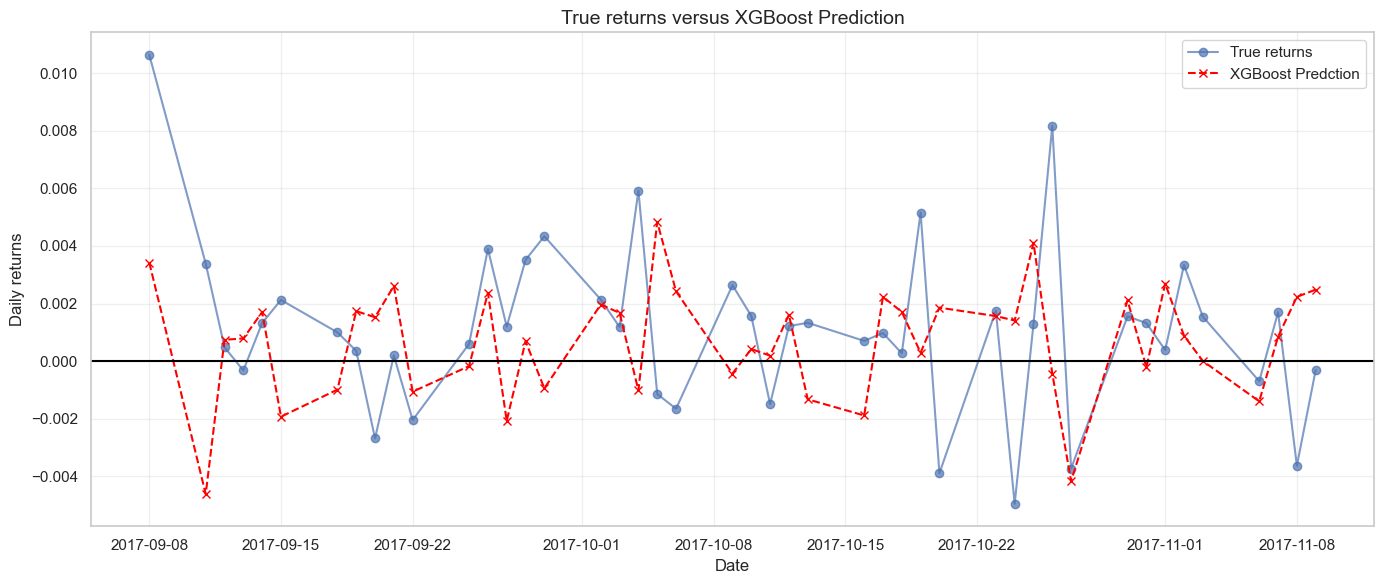

In [ ]:
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(y_test.index[-last_days:], y_test.iloc[-last_days:], 
         label='True returns', marker='o', alpha=0.7)
plt.plot(y_test.index[-last_days:], y_pred[-last_days:], 
         label='XGBoost Predction', marker='x', linestyle='--', color='red')
plt.title('True returns versus XGBoost Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') 

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

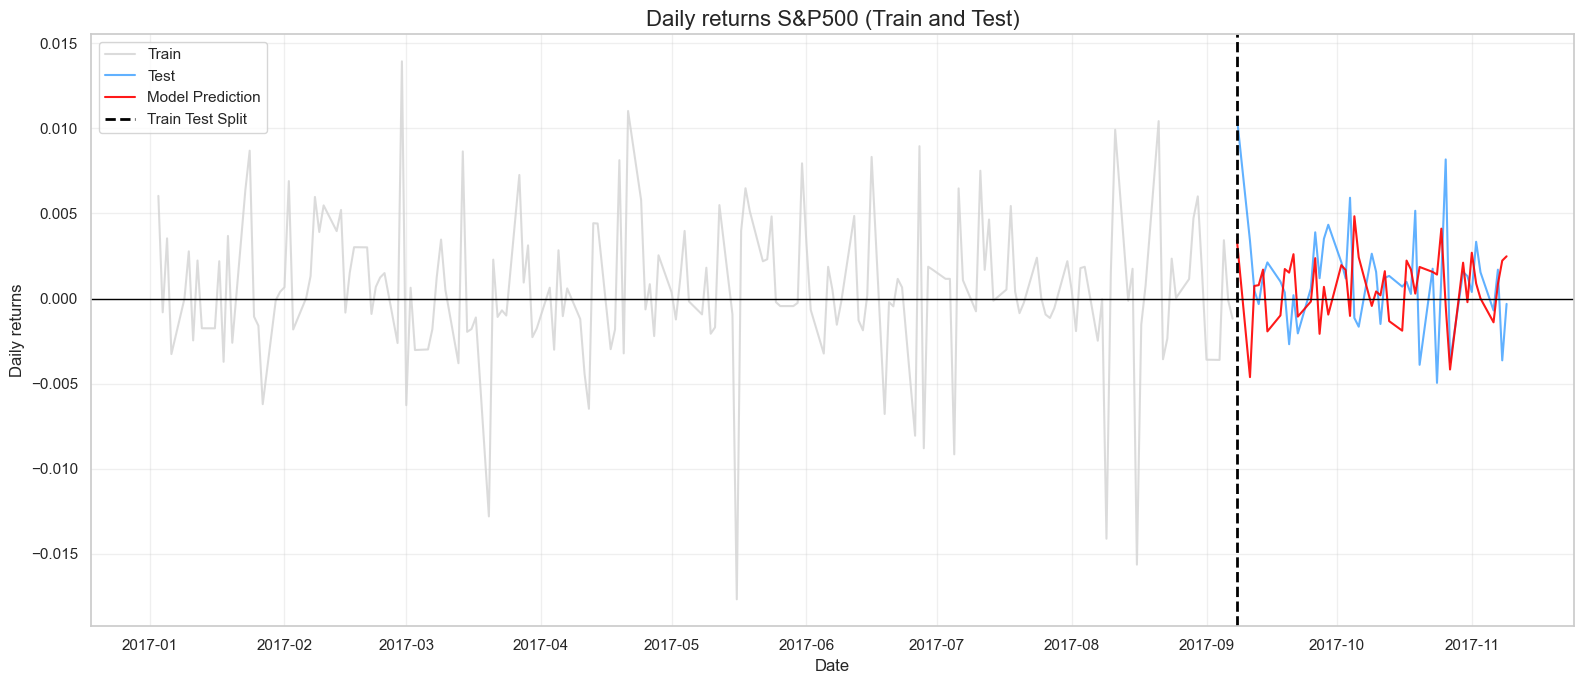

In [ ]:
plt.figure(figsize=(16, 7))
plt.plot(y_train.index, y_train, label='Train', color='lightgray', alpha=0.8)
plt.plot(y_test.index, y_test, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=y_test.index[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
model = lgb.LGBMRegressor(n_estimators = 100, learning_rate = 0.05, num_leaves = 8, max_depth = 3, random_state = 42, verbose = -1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 0.0028690812112551495


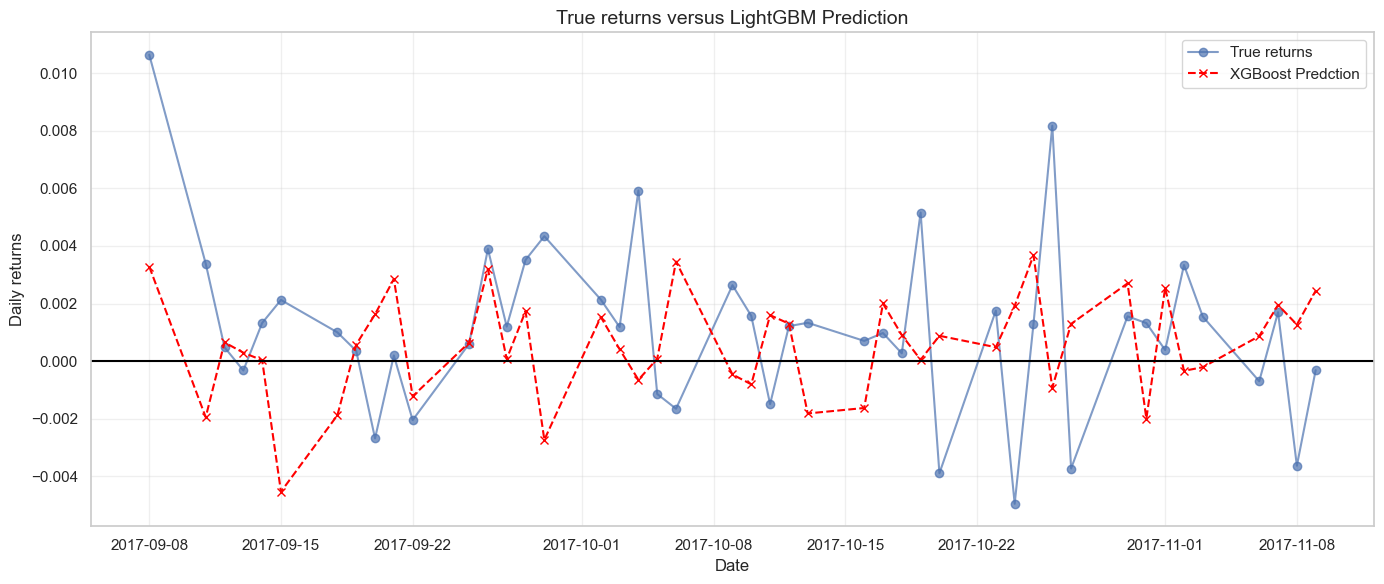

In [ ]:
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(y_test.index[-last_days:], y_test.iloc[-last_days:], 
         label='True returns', marker='o', alpha=0.7)
plt.plot(y_test.index[-last_days:], y_pred[-last_days:], 
         label='XGBoost Predction', marker='x', linestyle='--', color='red')
plt.title('True returns versus LightGBM Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') 

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

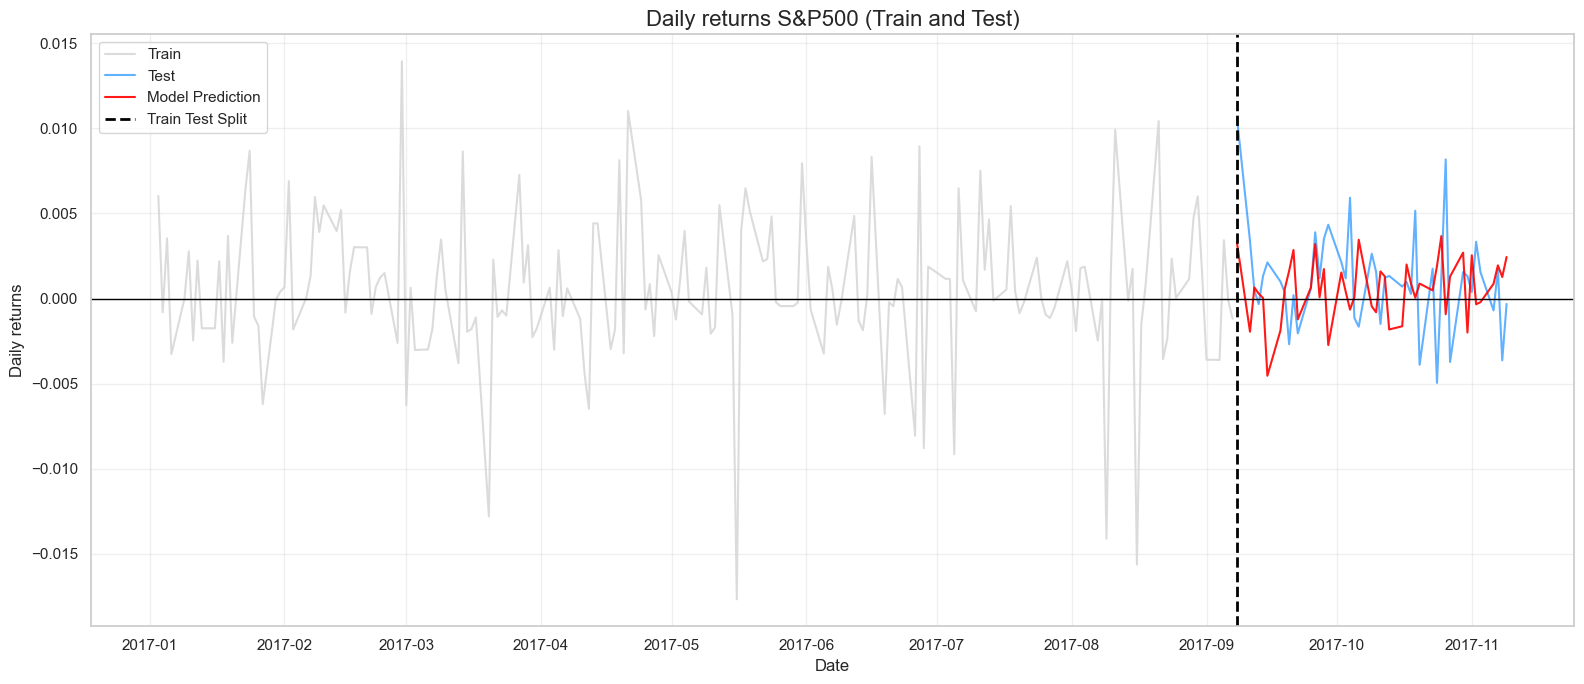

In [ ]:
plt.figure(figsize=(16, 7))
plt.plot(y_train.index, y_train, label='Train', color='lightgray', alpha=0.8)
plt.plot(y_test.index, y_test, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=y_test.index[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
SEQ_LEN = 10 

X_values = X.values  
y_values = y.values

X_seq = []
y_seq = []

for i in range(len(X_values) - SEQ_LEN):
    window_X = X_values[i : i + SEQ_LEN]
    target_y = y_values[i + SEQ_LEN]
    
    X_seq.append(window_X)
    y_seq.append(target_y)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(f"Stary kształt X: {X.shape} -> (Liczba wierszy, Liczba spółek)")
print(f"Nowy kształt X_seq: {X_seq.shape} -> (Liczba paczek, Dni w paczce, Liczba spółek)")

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, 
    test_size=0.2, 
    shuffle=False 
)

Stary kształt X: (223, 12) -> (Liczba wierszy, Liczba spółek)
Nowy kształt X_seq: (213, 10, 12) -> (Liczba paczek, Dni w paczce, Liczba spółek)


In [ ]:
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32)

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False) 

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dane gotowe do treningu! Liczba porcji (batchy) w zbiorze treningowym: {len(train_loader)}")

NameError: name 'torch' is not defined